This is the code for generating Movie S1-7a.

More information about LaMEM.jl can be found at https://github.com/JuliaGeodynamics/LaMEM.jl."

#### Read and plot individual timestep from the current folder

In [1]:
using Plots, LaMEM, GeophysicalModelGenerator, Colors, Statistics, SavitzkyGolay, CSV, ColorSchemes, DataFrames

gr()  # use the GR backend

# Define the current folder and server details
local_folder = pwd()  # Get the current working directory
this_folder = basename(pwd()) 

println("local_folder: ", local_folder)

# Append /output after the current working directory
model_output = joinpath(local_folder, "output")
println("model_output: ", model_output)

[ Info: Precompiling LaMEM [2e889f3d-35ce-4a77-8ea2-858aecb630f7] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
┌ Info: Skipping precompilation due to precompilable error. Importing LaMEM [2e889f3d-35ce-4a77-8ea2-858aecb630f7].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
[ Info: Precompiling PlotsExt [a2d34823-e7d1-5415-b9a5-cbcf7df71915] 

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
┌ Warning: Module LaMEM with build ID ffffffff-ffff-ffff-0ab8-795b66e14ae0 is missing from the cache.
│ This may mean LaMEM [2e889f3d-35ce-4a77-8ea2-858aecb630f7] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2641
┌ Info: Skipping precompilation du

Adding Plots.jl plotting extensions for LaMEM
local_folder: /Volumes/T7/HR/Ref
model_output: /Volumes/T7/HR/Ref/output


In [ ]:
z_resolution = 1 #km
compensation_density = 3170.8# 70km 3226# density at 135km ,3170.8#70km  #3163.5 ,density at -200km
compensation_depth = -200#-200km
interval = 200 # plotting
boundary =1000 # plotting
arc_upper_crust_phase = 17 #phase number
arc_lower_crust_phase = 18 #phase number
mid_ocean_ridge_depth = -2.6#km
topo_error = -0.1#km; Align the distal LIT and ST
arc_range_shift = 0 # if the rang of arc to the trench change
# Directory for model output and where to save plots
plots_dir =joinpath(local_folder, "plots_isostatic_arc_smooth_no_ecl_$(-compensation_depth)_v12_3")

"/Volumes/T7/HR/Ref/plots_isostatic_arc_smooth_no_ecl_200_thickening_12v_3"

In [ ]:
# for equation 1
rho_m=3300 #kg/m^3 mantle lithosphere density
rho_c=2800 #kg/m^3 crustal density
d0=35000 #m crustal thickness linked to sea level
h0=0 #m sea level

0

In [4]:
# Ensure the plots directory exists
isdir(plots_dir) || mkdir(plots_dir)

true

In [5]:
my_colors = [
    "#FFFFFF",  # 0: air
    "#264e86",  # 1: asthenospheric mantle
    "#6eb6ff",  # 2: oceanic litho mantle
    "#7098da",  # 3: indian litho mantle
    "#7098da",  # 4: asian litho mantle
    "#7098da",  # 5: weakzone box mantle
    "#7098da",  # 6: weakzone slab
    "#7098da",  # 7: weakzone box
    "#7874f2",  # 8: arc litho mantle
    "#2eb872",  # 9: eclogite
    "#2eb872",  # 10: oceanic crust
    "#f0b775",  # 11: weakzone box crust
    "#f0b775",  # 12: asian upper crust
    "#f0b775",  # 13: asian lower crust
    "#f0b775",  # 14: indian sediment
    "#f0b775",  # 15: indian upper crust
    "#f0b775",  # 16: indian lower crust
    "#ef255f",  # 17: arc upper crust
    "#ef255f"   # 18: arc lower crust
]
# #Color scheme with Indian lower crust eclogitization.
# my_colors = [
#     "#FFFFFF",  # 0: air
#     "#264e86",  # 1: asthenospheric mantle
#     "#6eb6ff",  # 2: oceanic litho mantle
#     "#7098da",  # 3: indian litho mantle
#     "#7098da",  # 4: asian litho mantle
#     "#7098da",  # 5: weakzone box mantle
#     "#7098da",  # 6: weakzone slab
#     "#7098da",  # 7: weakzone box
#     "#7874f2",  # 8: arc litho mantle
#     "#2eb872",  # 9: eclogite
#     "#2eb872",  # 10: oceanic crust
#     "#f0b775",  # 11: weakzone box crust
#     "#f0b775",  # 12: asian upper crust
#     "#f0b775",  # 13: asian lower crust
#     "#f0b775",  # 14: indian sediment
#     "#f0b775",  # 15: indian upper crust
#     "#f0b775",  # 16: indian lower crust
#     "#f0b775",  # 17: indian lower crust eclogizitation
#     "#ef255f",  # 18: arc upper crust
#     "#ef255f",  # 19: arc lower crust
#     "#8C5A3C"   # 20: eclogite_crust
# ]

19-element Vector{String}:
 "#FFFFFF"
 "#264e86"
 "#6eb6ff"
 "#7098da"
 "#7098da"
 "#7098da"
 "#7098da"
 "#7098da"
 "#7874f2"
 "#2eb872"
 "#2eb872"
 "#f0b775"
 "#f0b775"
 "#f0b775"
 "#f0b775"
 "#f0b775"
 "#f0b775"
 "#ef255f"
 "#ef255f"

In [6]:
# Read all available time steps
all_timesteps, Filenames, time = read_LaMEM_simulation(model_output)
cart_data, _ = read_LaMEM_timestep(model_output,0)
x = cart_data.x.val[:,1,1]
z = cart_data.z.val[1,1,:]
density = cart_data.fields.density[:,1,:]
println(typeof(time), size(time))
println(typeof(x), size(x))
println(typeof(z), size(z))
println(typeof(density), size(density))


Vector{Float64}(171,)
Vector{Float64}(801,)
Vector{Float64}(321,)
Matrix{Float32}(801, 321)


In [7]:
# read somthing from tracer
cart_data_tracer,_ = read_LaMEM_timestep(model_output, 0, passive_tracers=true)

phase_tracer = cart_data_tracer.fields.Phase[:,1,:]
ID_tracer = cart_data_tracer.fields.ID[:,1,:]

arc_crust_ID_index = (phase_tracer .== arc_upper_crust_phase) .| (phase_tracer .== arc_lower_crust_phase )  
arc_crust_ID = Int64.(ID_tracer[arc_crust_ID_index])

PT = passivetracer_time(arc_crust_ID, model_output)
x_passive_tracer = PT. x
z_passive_tracer = PT. z

# Store crustal thickness at each time step
crustal_thickness_time = zeros(Float64, length(time))  # 1D array, length = 3500 * 113

isostatic_elevation_arc = zeros(Float64, length(time))
arc_elevation = zeros(Float64, length(time), 3)
isostatic_elevation_arc_total = zeros(Float64, length(time))

time_topo = zeros(Float64, length(time), length(x))
# Store arc boundary at each time step
arc_boundary = zeros(Float64, length(time), 2)

# z_index = findall(x -> x > compensation_depth, z)
# println(z_index )

171×2 Matrix{Float64}:
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 ⋮    
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0
 0.0  0.0

In [ ]:
z_index = findall(x -> x > compensation_depth, z)
isostatic_time_topo = fill(mid_ocean_ridge_depth, length(time), length(x))

# Iterate over each time step and plot the results
for i in 1:length(all_timesteps)
    cart_data, _ = read_LaMEM_timestep(model_output, all_timesteps[i])
    # ======================================= calculate isostatic elevation from density field 
    #density = cart_data.fields.density[:,1,:]
    for j in 1:length(x)
        for m in z_index
            if cart_data.fields.density[j,1,m] > 2000 && cart_data.fields.density[j,1,m] < 3300
                isostatic_time_topo[i,j] += (compensation_density - cart_data.fields.density[j,1,m]) /compensation_density * z_resolution
            elseif cart_data.fields.density[j,1,m] >= 3300  
                continue
            else
                break
            end
        end
    end

    smooth_result = savitzky_golay(isostatic_time_topo[i,:], 13, 2)
    isostatic_time_topo_smooth = smooth_result.y

    # ======================================= extract phase field
    phase = cart_data.fields.phase[:,1,:]

    # ======================================= extract topo
    topo_data, _ = read_LaMEM_timestep(model_output, all_timesteps[i], surf=true)
    topo = topo_data.fields.topography[:,1,1] .+ topo_error
    time_topo[i,:] = topo
    # ======================================= extract crustal thickness of arc, calculate the isostatic elevation from passive tracer 
    # ============== extract arc thickness
    # Group by x-coordinate
    grouping = floor.(Int, x_passive_tracer[:,i] ./ 2) .+ 1
    groups_number = unique(grouping)
    crustal_thickness_group = zeros(Float64, length(groups_number))

    for (j_index, j) in enumerate(groups_number)
        # Find indices belonging to the current group
        idx = findall(grouping .== j)
        # Calculate thickness for this group: max(z) - min(z)
        crustal_thickness_group[j_index] = maximum(z_passive_tracer[:,i][idx]) - minimum(z_passive_tracer[:,i][idx]) 
    end

    # +1 to correct for resolution error (theoretical initial thickness is 35)
    crustal_thickness_time[i] = median(crustal_thickness_group) #.+1
    
    isostatic_elevation_arc[i] = (rho_m - rho_c) / rho_m * (crustal_thickness_time[i]* 1000 .- d0) ./1000
    
    # ============== Extract arc boundary range again
    # Group by y-coordinate
    grouping_z = floor.(Int, z_passive_tracer[:,i] ./ 2) .+ 1
    groups_number_z = unique(grouping_z)
    arc_boundary_group = zeros(Float64, length(groups_number_z), 2)
 
    for (j_index, j) in enumerate(groups_number_z)
        # Find indices belonging to the current group
        idx_z = findall(grouping_z .== j)
        # Calculate thickness for this group: max(z) - min(z)
        arc_boundary_group[j_index,1] = minimum(x_passive_tracer[:,i][idx_z]) 
        arc_boundary_group[j_index,2] = maximum(x_passive_tracer[:,i][idx_z])
    end
 
    arc_boundary[i,1] = median(arc_boundary_group[:,1])
    arc_boundary[i,2] = median(arc_boundary_group[:,2])

    # ======================================= Extract average of total isostasy and actual topography within arc range
    idx_x_isostasy = findall((x .> arc_boundary[i,1]) .& (x .< arc_boundary[i,2]))
    idx_x = findall((x .> arc_boundary[i,1]-arc_range_shift) .& (x .< arc_boundary[i,2]+arc_range_shift))
    
    arc_elevation[i, 1] = median(topo[idx_x])
    arc_elevation[i, 2] = maximum(topo[idx_x])
    arc_elevation[i, 3] = minimum(topo[idx_x])

    isostatic_elevation_arc_total[i] = median(isostatic_time_topo[i,:][idx_x_isostasy])
    # ======================================= plotting 
    p1 = heatmap(x, z, phase', xlabel="km", ylabel="km", title="Phase @ t=$(time[i])",
    color  = cgrad(my_colors; categorical=true),  
    clims  = (-0.5, 18.5), xlims=(-boundary , boundary), ylims=(-500, 20), aspect_ratio=1, colorbar=false, xticks=-boundary:interval:boundary) #    clims  = (-0.5, 20.5) with eclogitization

    p2 = plot(x, topo , title="Topography @ t=$(time[i])",
        ylabel="km", xlims=(-boundary-20, boundary+20), ylims=(-7, 8), grid=true, legend=false,
        xticks=-boundary:interval:boundary)
    plot!(p2, x, isostatic_time_topo_smooth, label="Isostatic elevation", linewidth=2, color=:orange)
    plot!(p2, [arc_boundary[i,1], arc_boundary[i,2]], [isostatic_elevation_arc[i], isostatic_elevation_arc[i]], label="arc isostatic elevation", linewidth=2, color=:red)

    combined_plot = plot(p2, p1, layout=(2,1), link=:x, dpi= 400)

    # Format both timestep and counter numbers
    formatted_timestep = lpad(all_timesteps[i], 5, '0') # Pad timestep number to five digits
    formatted_counter = lpad(i, 5, '0')   # Pad counter number to five digits

    # Save the plot with both numbers in the filename
    savefig(combined_plot, "$(plots_dir)/plot_$(formatted_counter)_timestep_$(formatted_timestep)_isostatic_v12_3.png")

    
end

In [10]:
# Output video file paths
output_video_1 = joinpath(plots_dir, "$(this_folder)_output_video.mp4")  
# ffmpeg command to create a video from "plot_*.png"
ffmpeg_command_1 = `ffmpeg -r 30 -pattern_type glob -i $(joinpath(plots_dir, "plot_*_isostatic_v12_3.png")) -pix_fmt yuv420p -r 30 $(output_video_1)`
# Run ffmpeg to create the first video
run(ffmpeg_command_1)

ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.4)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1_4 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --e

Process(`ffmpeg -r 30 -pattern_type glob -i '/Volumes/T7/HR/Ref/plots_isostatic_arc_smooth_no_ecl_200_thickening_12v_3/plot_*_isostatic_v12_3.png' -pix_fmt yuv420p -r 30 /Volumes/T7/HR/Ref/plots_isostatic_arc_smooth_no_ecl_200_thickening_12v_3/Ref_output_video.mp4`, ProcessExited(0))

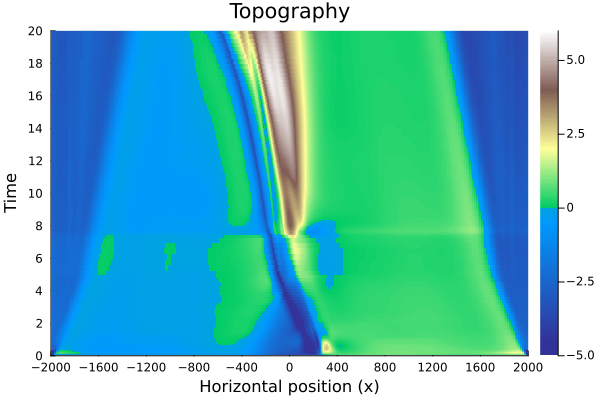

In [11]:
# Set critical elevation for the color bar (crit must be less than 0)
crit = -4.5

# Define data range
cmin, cmax = -5, 6

# Calculate normalized position corresponding to 0, ensuring 0 is always fixed
norm_zero = (0 - cmin) / (cmax - cmin)   # (0+3)/9 = 0.3333

# Calculate normalized position corresponding to crit, ensuring it's not below the minimum data range
norm_crit = (crit - cmin) / (cmax - cmin)
norm_crit = max(norm_crit, 0)  # If crit is less than cmin, set norm_crit to 0


# Blue section: corresponds to the region from crit to 0, starting position:
blue_start = (norm_crit > 0 ? norm_crit : 0)
# Continue using the original ocean color scheme: sample colors from 0 to 0.17 of the terrain colormap
blue_colors = [get(ColorSchemes.terrain, t) for t in LinRange(0, 0.17, 256)]
blue_positions = LinRange(blue_start, norm_zero, 256)

# Land section: corresponds to the region from 0 to maximum value 6, normalized interval fixed at [norm_zero, 1]
land_colors = [get(ColorSchemes.terrain, t) for t in LinRange(0.25, 1, 256)]
land_positions = LinRange(norm_zero, 1, 256)

# Merge colors and normalized positions from both sections
all_colors = vcat(blue_colors, land_colors)
positions = vcat(blue_positions, land_positions)

# Create custom gradient
terrain_map = cgrad(all_colors, positions)

# Plot heatmap
p1 = heatmap(
    x, time, time_topo,
    color = terrain_map,
    clims = (cmin, cmax),
    xlabel = "Horizontal position (x)",
    ylabel = "Time",
    title = "Topography",
    xlims = (-2000, 2000), 
    ylims = (0, 20), 
    xticks=-2000:400:2000,
    yticks=0:2:20
)
p1_dpi = plot(p1, dpi= 400)
# Save PNG file with transparent background
savefig(p1_dpi, "plot_topography_time_$(this_folder)_v12_3.png")  # Default white background
display(p1)

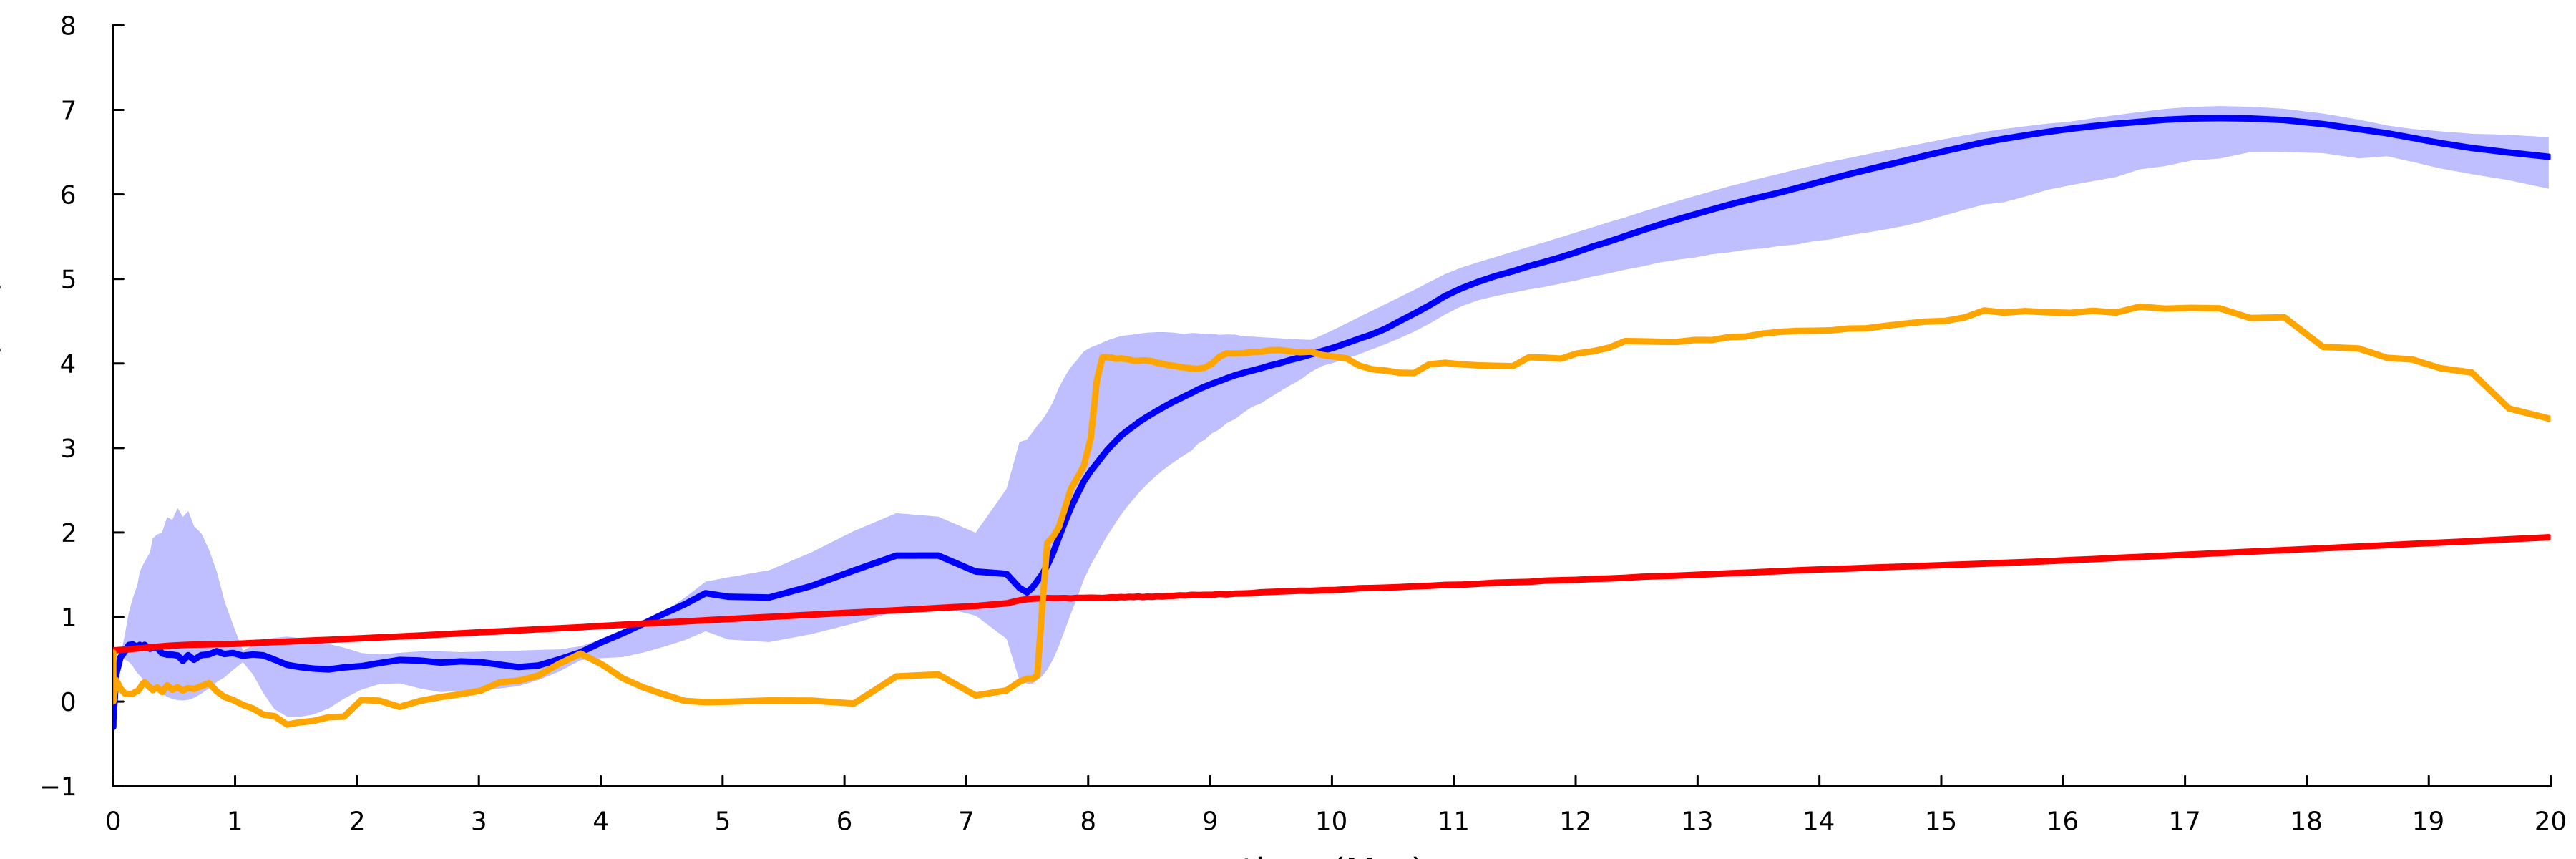

"/Volumes/T7/HR/Ref/plot_isostatic_elevation_Ref_200_uplifting_0.0714_12v_3.png"

In [ ]:
# Plot ST, LIT, and GCIT versus time (accounting for uplift due to magmatic thickening)
uplift_rate = 0.0714 # The surface uplift rate due to magmatic thickening scales with the thickening rate (derived from equation 1): 0.0714 km/Myr corresponds to a magmatic thickening rate of 0.5 km/Myr, and 0.143 km/Myr corresponds to 1 km/Myr; 0 km/Myr without magmatic thickening.
arc_elev_median_uplifted = arc_elevation[:,1] .+ time .* uplift_rate
arc_elev_max_uplifted     = arc_elevation[:,2] .+ time .* uplift_rate
arc_elev_min_uplifted     = arc_elevation[:,3] .+ time .* uplift_rate

isostatic_arc_uplifted    = isostatic_elevation_arc .+ time .* uplift_rate
isostatic_total_uplifted  = isostatic_elevation_arc_total .+ time .* uplift_rate


p1 = plot(time, arc_elev_median_uplifted,
    ylabel="elevation (km)",
    xlabel="time (Myr)", 
    xlims=(0,20), ylims=(-1,8),
    grid=false, 
    xticks=0:1:20, yticks=-3:1:8,
    size=(1200,400),
    linewidth=3,
    color=:blue,
    dpi=300,
    bg=:transparent,
    legend=false)

plot!(p1, time, arc_elev_max_uplifted;
      fillrange = arc_elev_min_uplifted,
      linewidth = 0,
      fillalpha = 0.25,
      color = :blue)

plot!(p1, time, isostatic_arc_uplifted, linewidth=3, color=:red)

plot!(p1, time, isostatic_total_uplifted, linewidth=3, color=:orange)


display(p1)
# Save PNG file with transparent background
savefig(p1, "plot_isostatic_elevation_$(this_folder)_$(-compensation_depth)_uplifting_$(uplift_rate)_12v_3.png")  # Default white background

In [ ]:
# DataFrame, ST from the arc region over time
df = DataFrame(
    time = time,
    arc_ST_median = arc_elevation[:, 1],
    arc_ST_maximum = arc_elevation[:, 2],
    arc_ST_minimum = arc_elevation[:, 3],
)
data_file = joinpath(local_folder, "data_$(this_folder).csv")
CSV.write(data_file, df)

"/Volumes/T7/HR/Ref/data_Ref.csv"